<a href="https://colab.research.google.com/github/likhithapotluri/AAI_520_Test_Prj/blob/main/AAI520_Investment_Agent_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAI-520: Investment Research Agent — Final Team Project

**Team members:** _add names here_
**GitHub Repository:** _add link here — required for submission_
**Data sources:** Yahoo Finance (`yfinance`) — prices, financials, news · FRED — macro indicators
**LLM:** Google Gemini (`gemini-3.5-flash-lite`) via the free tier in Google AI Studio

This notebook implements an autonomous Investment Research Agent for a given
stock ticker. Given a ticker (and an optional research focus), the agent
plans its own research steps, calls data tools dynamically, routes findings
to specialist analysts, drafts and iteratively improves a report, reflects
on its own process, and remembers notes across runs.

**Covers:**
- **Agent Functions:** planning, dynamic tool use, self-reflection, memory across runs
- **Workflow Patterns:** prompt chaining (news pipeline), routing (specialist analysts), evaluator–optimizer (iterative report refinement)

Write-up sections (Agent Design and Workflows / Agent Functions and
Capabilities / Evaluation and Iteration) and the submission checklist are
near the end of this notebook.


In [1]:
!pip install google-genai yfinance

In [2]:
from google.colab import userdata
from google import genai

api_key = userdata.get("GEMINI_API_KEY")
print("Key found:", api_key is not None)  # prints True/False, never the key itself

MODEL = "gemini-3.5-flash-lite"

client = genai.Client(api_key=api_key)
response = client.models.generate_content(
    model=MODEL,
    contents="Say hello in one sentence.",
)
print(response.text)

Key found: True
Hello, it is great to meet you today!


## Setup: LLM Call Wrapper (Gemini)

In [3]:
import time

MODEL = "gemini-3.5-flash-lite"
_cache = {}


def llm_call(prompt, model=MODEL, retries=3):
    """Send a prompt to Gemini and return the text. Caches repeat prompts."""
    key = (model, prompt)
    if key in _cache:
        return _cache[key]
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model=model, contents=prompt
            )
            _cache[key] = response.text
            return response.text
        except Exception as e:
            print(f"LLM call failed (attempt {attempt + 1}): {str(e)[:100]}")
            time.sleep(5 * (attempt + 1))
    raise RuntimeError("LLM call failed after retries")

## Tool: Price Data (yfinance)

In [4]:
import yfinance as yf


def get_price_summary(ticker, period="3mo"):
    """Fetch price history and return a compact summary dict."""
    hist = yf.Ticker(ticker).history(period=period)
    if hist.empty:
        return {"error": f"No price data found for {ticker}"}
    first = hist["Close"].iloc[0]
    last = hist["Close"].iloc[-1]
    return {
        "ticker": ticker,
        "period": period,
        "last_close": round(float(last), 2),
        "change_pct": round(float((last / first - 1) * 100), 1),
        "period_high": round(float(hist["High"].max()), 2),
        "period_low": round(float(hist["Low"].min()), 2),
        "avg_daily_volume": int(hist["Volume"].mean()),
    }


data = get_price_summary("AAPL")
print(data)

{'ticker': 'AAPL', 'period': '3mo', 'last_close': 338.98, 'change_pct': 14.2, 'period_high': 344.27, 'period_low': 273.51, 'avg_daily_volume': 53162876}


### Demo: Tool + LLM Together

In [5]:
prompt = f"""You are a market analyst. Using ONLY the data below, write a
3-sentence market view. Do not invent any numbers.

Data: {data}"""

print(llm_call(prompt))

Over the trailing 3-month period, AAPL closed at 338.98, reflecting a strong positive change of 14.2%. During this timeframe, the stock fluctuated between a period low of 273.51 and a period high of 344.27. Trading activity averaged an average daily volume of 53,162,876 shares over the 3-month duration.


In [6]:
def _pct(x):
    """Convert a decimal ratio (0.164) to a percentage (16.4)."""
    return round(x * 100, 2) if isinstance(x, (int, float)) else None

## Tool: Financials Data (yfinance)

In [7]:
def get_financials(ticker):
    """Fetch key company metrics and the latest quarterly results."""
    t = yf.Ticker(ticker)
    info = t.info or {}
    result = {
        "ticker": ticker,
        "company": info.get("shortName"),
        "sector": info.get("sector"),
        "market_cap": info.get("marketCap"),
        "trailing_pe": info.get("trailingPE"),
        "forward_pe": info.get("forwardPE"),
        "profit_margin_pct": _pct(info.get("profitMargins")),
        "revenue_growth_yoy_pct": _pct(info.get("revenueGrowth")),
        "debt_to_equity_pct": info.get("debtToEquity"),
    }
    try:
        q = t.quarterly_income_stmt
        latest = q.columns[:2]  # two most recent quarters
        result["recent_quarters"] = {
            str(col.date()): {
                "revenue": float(q.loc["Total Revenue", col]),
                "net_income": float(q.loc["Net Income", col]),
            }
            for col in latest
        }
    except Exception as e:
        result["recent_quarters"] = f"unavailable ({type(e).__name__})"
    return result


fin = get_financials("AAPL")
print(fin)

{'ticker': 'AAPL', 'company': 'Apple Inc.', 'sector': 'Technology', 'market_cap': 4947135430656, 'trailing_pe': 38.918484, 'forward_pe': 35.352398, 'profit_margin_pct': 27.62, 'revenue_growth_yoy_pct': 16.4, 'debt_to_equity_pct': 78.445, 'recent_quarters': {'2026-06-30': {'revenue': 109417000000.0, 'net_income': 29789000000.0}, '2026-03-31': {'revenue': 111184000000.0, 'net_income': 29578000000.0}}}


## Tool: News Data (yfinance)

In [8]:
def get_news(ticker, limit=5):
    """Fetch recent news items as a list of simple dicts."""
    raw = yf.Ticker(ticker).news or []
    items = []
    for n in raw[:limit]:
        c = n.get("content", n)  # newer format nests data under "content"
        items.append({
            "title": c.get("title"),
            "summary": c.get("summary") or c.get("description"),
            "publisher": (c.get("provider") or {}).get("displayName")
                         or n.get("publisher"),
            "date": c.get("pubDate") or n.get("providerPublishTime"),
        })
    return items


news = get_news("AAPL")
for item in news:
    print(item["title"], "|", item["publisher"], "|", item["date"])

Meta stock jumps as Wells Fargo raises price target | Yahoo Finance Video | 2026-09-21T19:52:00Z
Apple’s new iPhone Duo: Will consumers bite? | Yahoo Finance Video | 2026-09-21T17:41:00Z
Warren Buffett Just Stepped Down. These 2 AI Stocks Still Define Berkshire’s Portfolio | Insider Monkey | 2026-09-22T07:30:51Z
TSLA, SPCX, AAPL Could Be Next To ‘Rip’ After Meta’s Muse Rally, Analyst Says — Here Are The Catalysts | Stocktwits | 2026-09-22T06:02:01Z
Meta Stock Is Still Too Cheap | Motley Fool | 2026-09-22T04:50:02Z


## Workflow Pattern 1: Prompt Chaining — Ingest & Preprocess News

In [9]:
import json
import re


def llm_json(prompt, retries=2):
    """Call the LLM and parse its reply as JSON. Retries with a stricter
    prompt if the reply is not valid JSON, instead of trusting a cached
    failure."""
    last_error = None
    for attempt in range(retries + 1):
        p = prompt if attempt == 0 else (
            prompt + "\n\nIMPORTANT: your previous reply was not valid JSON. "
            "Return ONLY valid JSON: double quotes, escape any double quotes "
            "inside strings, no trailing commas, no text outside the JSON. "
            f"(retry {attempt})")
        text = llm_call(p).strip()
        text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text)
        try:
            return json.loads(text)
        except json.JSONDecodeError as e:
            match = re.search(r"(\[.*\]|\{.*\})", text, re.DOTALL)
            if match:
                try:
                    return json.loads(match.group(1))
                except json.JSONDecodeError:
                    pass
            last_error = e
            print(f"   JSON parse failed (attempt {attempt + 1}): {str(e)[:60]}")
    raise last_error


def preprocess_news(items, max_chars=400):
    """Step 2: clean text, drop duplicates/empties, assign ids."""
    seen, clean = set(), []
    for item in items:
        title = (item.get("title") or "").strip()
        if not title or title.lower() in seen:
            continue
        seen.add(title.lower())
        summary = re.sub(r"<[^>]+>", "", item.get("summary") or "")
        clean.append({
            "id": len(clean) + 1,
            "title": title,
            "summary": summary.strip()[:max_chars],
            "publisher": item.get("publisher"),
            "date": item.get("date"),
        })
    return clean

### Prompt Chaining — Classify, Extract, Summarize

In [10]:
def classify_news(ticker, articles):
    """Step 3: label each article."""
    prompt = f"""You are classifying news for the stock {ticker}.
For each article, return a JSON list of objects with exactly these keys:
"id" (int), "relevant" (true/false: is it mainly about {ticker}?),
"category" (one of: earnings, product, analyst_rating, macro, legal, other),
"sentiment" (positive, negative, or neutral for {ticker}).
Return ONLY the JSON list, no other text.

Articles: {json.dumps(articles)}"""
    return llm_json(prompt)


def extract_facts(ticker, articles):
    """Step 4: pull key facts from relevant articles only."""
    prompt = f"""From each article below, extract up to 3 key facts about {ticker}.
Use ONLY information in the text. Do not invent anything.
Return a JSON list of objects: {{"id": int, "facts": [strings]}}.
Return ONLY the JSON list, no other text.

Articles: {json.dumps(articles)}"""
    return llm_json(prompt)


def summarize_news(ticker, classified, facts):
    """Step 5: write the final news summary."""
    prompt = f"""Write a 4-sentence news summary for {ticker} using ONLY the
data below. Mention the overall sentiment and the main themes.
Do not invent facts.

Classifications: {json.dumps(classified)}
Extracted facts: {json.dumps(facts)}"""
    return llm_call(prompt)

### Prompt Chaining — Full 5-Step Pipeline (Demo)

In [11]:
def run_news_chain(ticker):
    raw = get_news(ticker, limit=8)                       # Step 1: ingest
    articles = preprocess_news(raw)                       # Step 2: preprocess
    print(f"Step 2: {len(articles)} clean articles")

    labels = classify_news(ticker, articles)              # Step 3: classify
    print("Step 3: classification")
    for row in labels:
        print("  ", row)

    relevant_ids = {r["id"] for r in labels if r.get("relevant")}
    relevant = [a for a in articles if a["id"] in relevant_ids]
    print(f"Step 3 kept {len(relevant)} of {len(articles)} as relevant")

    facts = extract_facts(ticker, relevant)               # Step 4: extract
    print("Step 4: extracted facts")
    for row in facts:
        print("  ", row)

    summary = summarize_news(ticker, labels, facts)       # Step 5: summarize
    print("\nStep 5: summary\n", summary)
    return {"articles": articles, "labels": labels,
            "facts": facts, "summary": summary}


news_result = run_news_chain("AAPL")

Step 2: 8 clean articles
Step 3: classification
   {'id': 1, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 2, 'relevant': True, 'category': 'product', 'sentiment': 'neutral'}
   {'id': 3, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 4, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 5, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 6, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 7, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 8, 'relevant': True, 'category': 'product', 'sentiment': 'positive'}
Step 3 kept 2 of 8 as relevant
Step 4: extracted facts
   {'id': 2, 'facts': ['Apple (AAPL) introduced a new product called the iPhone Duo.', "Experts discussed consumer demand and the competitive smartphone landscape for Apple's new iPhone Duo."]}
   {'id': 8, 'facts': ['John Ternus is the new CEO of Apple, coming from the hardwar

## Workflow Pattern 2: Routing

### Routing — Build Items to Route

In [12]:
ROUTES = ["earnings", "news", "market"]


def build_research_items(ticker, price, fin, news_result):
    """Collect price data, financials and relevant news into one item list."""
    items = [
        {"id": 1, "text": f"Price data: {json.dumps(price)}"},
        {"id": 2, "text": f"Company financials: {json.dumps(fin)}"},
    ]
    relevant_ids = {r["id"] for r in news_result["labels"] if r.get("relevant")}
    for a in news_result["articles"]:
        if a["id"] in relevant_ids:
            items.append({
                "id": len(items) + 1,
                "text": f"News ({a['publisher']}): {a['title']}. {a['summary']}",
            })
    return items

### Routing — Router and Specialist Analysts

In [13]:
def route_items(ticker, items):
    """Router: the LLM assigns each item to one specialist."""
    prompt = f"""You are a router for a stock research system on {ticker}.
Assign each item to exactly one specialist:
- "earnings": revenue, profit, margins, valuation ratios, earnings results
- "market": price movement, trading volume, analyst ratings, price targets, market conditions
- "news": product launches, strategy, legal or regulatory issues, hiring, partnerships, other company events
Return ONLY a JSON list of objects: {{"id": int, "route": "earnings" or "market" or "news", "reason": short string}}.

Items: {json.dumps(items)}"""
    decisions = llm_json(prompt)
    valid = {d["id"]: d for d in decisions if d.get("route") in ROUTES}
    for item in items:  # fallback if the router skipped or mislabelled an item
        if item["id"] not in valid:
            valid[item["id"]] = {"id": item["id"], "route": "news",
                                 "reason": "fallback: invalid router output"}
    return list(valid.values())


SPECIALISTS = {
    "earnings": "You are an earnings analyst. Focus on revenue, profit, margins, growth and valuation.",
    "market": "You are a market analyst. Focus on price trend, volume, analyst views and market conditions.",
    "news": "You are a news analyst. Focus on company events, products, strategy and risks.",
}


def run_specialist(ticker, route, items):
    prompt = f"""{SPECIALISTS[route]}
Stock: {ticker}. Write 3 sentences using ONLY the items below.
Do not invent numbers. Attribute promotional claims to their source
instead of stating them as fact.

Items: {json.dumps(items)}"""
    return llm_call(prompt)

### Routing — Run and Demonstrate

In [14]:
def run_routing(ticker, items):
    decisions = route_items(ticker, items)
    lookup = {i["id"]: i for i in items}
    by_route = {r: [] for r in ROUTES}

    print("Router decisions:")
    for d in decisions:
        print(f"  item {d['id']} -> {d['route']}: {d['reason']}")
        by_route[d["route"]].append(lookup[d["id"]])

    analyses = {}
    for route, group in by_route.items():
        if group:
            analyses[route] = run_specialist(ticker, route, group)
            print(f"\n[{route} analyst]\n{analyses[route]}")
    return decisions, analyses


price = get_price_summary("AAPL")
fin = get_financials("AAPL")
items = build_research_items("AAPL", price, fin, news_result)
decisions, analyses = run_routing("AAPL", items)

Router decisions:
  item 1 -> market: Contains stock price movement, percentage change, and volume data.
  item 2 -> earnings: Contains financial metrics, P/E ratios, profit margins, revenue, and net income.
  item 3 -> news: Discusses product launches, consumer demand, and market commentary from media.
  item 4 -> news: Reports on corporate events, leadership changes (CEO), and new product announcements.

[earnings analyst]
Apple Inc. trades at a trailing price-to-earnings ratio of 38.92 and a forward price-to-earnings ratio of 35.35, supporting a massive market capitalization of over $4.94 trillion. The technology company posted a year-over-year revenue growth of 16.4%, accompanied by a profit margin of 27.62%. During the quarter ending June 30, 2026, Apple generated $109,417,000,000 in revenue and $29,789,000,000 in net income, following the March 31, 2026 quarter where revenue reached $111,184,000,000 with $29,578,000,000 in net income.

[news analyst]
Apple launched new products, 

## Workflow Pattern 3: Evaluator–Optimizer

### Evaluator–Optimizer — Draft, Evaluate, Optimize Functions

In [15]:
RUBRIC = ["groundedness", "completeness", "balance", "clarity"]


def write_draft(ticker, analyses, context=""):
    """Generate: combine specialist analyses into one report."""
    prompt = f"""Write a concise investment research report on {ticker}.
Scope: {context}

Start with one line beginning "Scope:" that states the focus and the data used.
Then include ONLY the sections the analyses below support, chosen from:
Summary, Price and Market, Earnings and Financials, Macro Backdrop,
News and Events, Risks and Caveats.
Omit any section that has no data. Never write sentences about missing data,
"the provided analyses" or "the data source".
Risks and Caveats must come from the data itself (valuation, debt, price
range, macro conditions), not from what is absent.

Rules: attribute news claims by name ("According to Motley Fool, ...").
Use hedged wording for unconfirmed items ("hints at", "reportedly").
Use ONLY the analyses below. Do not invent facts. Keep the Summary
consistent with the sections.

Analyses: {json.dumps(analyses)}"""
    return llm_call(prompt)


def evaluate_report(ticker, report, items, context=""):
    """Evaluate: fact-check first, then score against the rubric."""
    prompt = f"""You are a strict fact-checker reviewing a stock research report on {ticker}.
RESEARCH SCOPE: {context}

Step 1: List every claim in the report that is NOT directly supported by the
SOURCE ITEMS, or that overstates a source (for example, a promotional or
unverified claim stated as fact, or a claim attributed to the company without
evidence). Also list any wording that refers to the writing process or to
missing data (for example "not provided in the data source").

Step 2: Score each criterion 1-10:
- groundedness: 6 or lower if any unsupported claim exists, 4 or lower if two or more
- completeness: covers everything inside the RESEARCH SCOPE; do NOT penalize
  topics that are outside the scope
- balance: risks and caveats drawn from the data, not just positives
- clarity: well organised and easy to read

Return ONLY JSON: {{"unsupported_claims": [strings],
"scores": {{"groundedness": int, "completeness": int, "balance": int, "clarity": int}},
"feedback": [specific fixes]}}

SOURCE ITEMS: {json.dumps(items)}

REPORT: {report}"""
    result = llm_json(prompt)
    scores = result["scores"]
    result["overall"] = round(sum(scores[k] for k in RUBRIC) / len(RUBRIC), 1)
    return result



def optimize_report(ticker, report, feedback, items, context=""):
    """Optimize: rewrite the report using the reviewer's feedback."""
    prompt = f"""Revise this research report on {ticker} to fix every problem
in the feedback. Use ONLY the source items. Remove any claim that the
source items do not support.
Scope: {context}

Rules: attribute news claims by name ("According to Motley Fool, ...").
Use hedged wording for unconfirmed items ("hints at", "reportedly").
Never write sentences about missing data or "the data source"; omit
sections that have no data. Keep the Summary consistent with the sections.

FEEDBACK: {json.dumps(feedback)}
SOURCE ITEMS: {json.dumps(items)}

REPORT: {report}"""
    return llm_call(prompt)

### Evaluator–Optimizer — Iteration Loop (Demo)

In [16]:
def run_evaluator_optimizer(ticker, analyses, items, context="",
                            threshold=8, max_iter=3):
    report = write_draft(ticker, analyses, context)
    history = []
    for i in range(1, max_iter + 1):
        review = evaluate_report(ticker, report, items, context)
        history.append({"iteration": i, "report": report, "review": review})
        print(f"Iteration {i}: scores={review['scores']}  overall={review['overall']}")
        for c in review["unsupported_claims"]:
            print("   unsupported:", c)
        for f in review["feedback"]:
            print("   feedback:", f)
        passed = review["overall"] >= threshold and not review["unsupported_claims"]
        if passed or i == max_iter:
            break
        fixes = review["unsupported_claims"] + review["feedback"]
        report = optimize_report(ticker, report, fixes, items, context)

    best = max(history, key=lambda h: (-len(h["review"]["unsupported_claims"]),
                                       h["review"]["overall"]))
    print(f"\nBest iteration: {best['iteration']} (overall={best['review']['overall']})")
    return best["report"], history

In [17]:
items = build_research_items("AAPL", price, fin, news_result)
decisions, analyses = run_routing("AAPL", items)

final_report, history = run_evaluator_optimizer("AAPL", analyses, items)

print("\n===== FIRST DRAFT =====\n", history[0]["report"])
print("\n===== FINAL REPORT =====\n", final_report)

Router decisions:
  item 1 -> market: Contains stock price movement, percentage change, and volume data.
  item 2 -> earnings: Contains financial metrics, P/E ratios, profit margins, revenue, and net income.
  item 3 -> news: Discusses product launches, consumer demand, and market commentary from media.
  item 4 -> news: Reports on corporate events, leadership changes (CEO), and new product announcements.

[earnings analyst]
Apple Inc. trades at a trailing price-to-earnings ratio of 38.92 and a forward price-to-earnings ratio of 35.35, supporting a massive market capitalization of over $4.94 trillion. The technology company posted a year-over-year revenue growth of 16.4%, accompanied by a profit margin of 27.62%. During the quarter ending June 30, 2026, Apple generated $109,417,000,000 in revenue and $29,789,000,000 in net income, following the March 31, 2026 quarter where revenue reached $111,184,000,000 with $29,578,000,000 in net income.

[news analyst]
Apple launched new products, 

## Agent Function: Planning & Dynamic Tool Use

### Tools Registry, Planner, and Executor

In [18]:
TOOLS = {
    "price": {
        "fn": get_price_summary,
        "desc": "3-month price summary: last close, change %, high/low, average volume",
    },
    "financials": {
        "fn": get_financials,
        "desc": "valuation ratios, margins, growth, debt, and the last two quarters of revenue and net income",
    },
    "news": {
        "fn": run_news_chain,
        "desc": "recent news run through the classify, extract and summarize chain",
    },
}


def make_plan(ticker, focus=None):
    """Planner: the LLM chooses which tools to use and in what order."""
    tool_list = "\n".join(f'- "{k}": {v["desc"]}' for k, v in TOOLS.items())
    prompt = f"""You are the planner of an investment research agent.
Stock: {ticker}
Research focus: {focus or "general investment overview"}

Available tools:
{tool_list}

Create a research plan of 1 to 3 steps. Each step uses exactly one tool,
and only tools that are useful for the focus. Order them logically.
Return ONLY a JSON list:
[{{"step": int, "tool": one of the tool names, "reason": short string}}]"""
    plan, used = [], set()
    try:
        for s in llm_json(prompt):
            if s.get("tool") in TOOLS and s["tool"] not in used:
                used.add(s["tool"])
                plan.append({"step": len(plan) + 1, "tool": s["tool"],
                             "reason": s.get("reason", "")})
    except Exception as e:
        print("Planner failed, using default plan:", type(e).__name__)
    if not plan:
        plan = [{"step": i + 1, "tool": t, "reason": "fallback: default plan"}
                for i, t in enumerate(TOOLS)]
    return plan


def execute_plan(ticker, plan):
    """Run the tools the planner chose. A failing tool never stops the agent."""
    results = {}
    for step in plan:
        name = step["tool"]
        print(f"\n>> Step {step['step']}: calling '{name}' ({step['reason']})")
        try:
            results[name] = TOOLS[name]["fn"](ticker)
        except Exception as e:
            print(f"   tool '{name}' failed: {type(e).__name__}: {str(e)[:80]}")
            results[name] = {"error": str(e)[:100]}
    return results

### Orchestration — `build_items_from_results` and `run_agent` (v1)

In [19]:
def build_items_from_results(results):
    """Turn tool results into router items; skip tools that failed or were not used."""
    items = []
    price = results.get("price")
    if price and "error" not in price:
        items.append({"id": len(items) + 1, "text": f"Price data: {json.dumps(price)}"})
    fin = results.get("financials")
    if fin and "error" not in fin:
        items.append({"id": len(items) + 1, "text": f"Company financials: {json.dumps(fin)}"})
    news = results.get("news")
    if news and "labels" in news:
        relevant_ids = {r["id"] for r in news["labels"] if r.get("relevant")}
        for a in news["articles"]:
            if a["id"] in relevant_ids:
                items.append({
                    "id": len(items) + 1,
                    "text": f"News ({a['publisher']}): {a['title']}. {a['summary']}",
                })
    return items


def run_agent(ticker, focus=None):
    print(f"===== Research agent: {ticker} | focus: {focus or 'general'} =====")
    plan = make_plan(ticker, focus)
    print("\nPLAN:")
    for s in plan:
        print(f"  {s['step']}. {s['tool']} - {s['reason']}")

    results = execute_plan(ticker, plan)
    items = build_items_from_results(results)
    if not items:
        print("No usable data was retrieved. Stopping.")
        return None

    tools_used = [n for n, r in results.items()
                  if not (isinstance(r, dict) and "error" in r)]
    context = (f"Research focus: {focus or 'general investment overview'}. "
               f"Data tools run: {', '.join(tools_used)}.")

    print("\n----- ROUTING -----")
    decisions, analyses = run_routing(ticker, items)

    print("\n----- EVALUATOR-OPTIMIZER -----")
    report, history = run_evaluator_optimizer(ticker, analyses, items,
                                              context=context)

    print("\n===== FINAL REPORT =====\n", report)
    return {"ticker": ticker, "focus": focus, "plan": plan, "results": results,
            "items": items, "decisions": decisions, "analyses": analyses,
            "report": report, "history": history}

### Demonstration Runs — AAPL and NVDA (Agent v1: planning, tool use, routing, evaluator–optimizer)

In [20]:
run1 = run_agent("AAPL")

===== Research agent: AAPL | focus: general =====

PLAN:
  1. price - Analyze recent price performance, volatility, and trading volume.
  2. financials - Evaluate valuation ratios, profitability margins, debt levels, and recent revenue/earnings.
  3. news - Review recent news developments and market sentiment to complete the general overview.

>> Step 1: calling 'price' (Analyze recent price performance, volatility, and trading volume.)

>> Step 2: calling 'financials' (Evaluate valuation ratios, profitability margins, debt levels, and recent revenue/earnings.)

>> Step 3: calling 'news' (Review recent news developments and market sentiment to complete the general overview.)
Step 2: 8 clean articles
Step 3: classification
   {'id': 1, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 2, 'relevant': True, 'category': 'product', 'sentiment': 'neutral'}
   {'id': 3, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 4, 'relevant': False, 'cat

In [21]:
run2 = run_agent("NVDA", focus="valuation and price trend only")

===== Research agent: NVDA | focus: valuation and price trend only =====

PLAN:
  1. price - Analyze recent price momentum, 3-month high/low, and volume trends for NVDA.
  2. financials - Examine current valuation ratios, margins, and recent quarterly performance.

>> Step 1: calling 'price' (Analyze recent price momentum, 3-month high/low, and volume trends for NVDA.)

>> Step 2: calling 'financials' (Examine current valuation ratios, margins, and recent quarterly performance.)

----- ROUTING -----
Router decisions:
  item 1 -> market: Contains price movement, trading volume, and period high/low data.
  item 2 -> earnings: Contains financial metrics, valuation ratios like P/E, profit margins, and quarterly revenue.

[earnings analyst]
NVIDIA Corporation (NVDA) boasts an exceptionally high trailing P/E ratio of 28.75 alongside a forward P/E of 14.50, underpinned by a massive market capitalization of over $5.49 trillion. The technology company achieved a stellar 105.9% year-over-year re

## Tool: Macro Data (FRED)

In [22]:
import io
import requests
import pandas as pd

FRED_SERIES = {
    "fed_funds_rate_pct": "FEDFUNDS",
    "unemployment_rate_pct": "UNRATE",
    "treasury_10y_yield_pct": "DGS10",
}


def _fred_series(series_id):
    """Download one FRED series as a clean date/value table (15 s timeout)."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text))
    df.columns = ["date", "value"]
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna()


def get_macro_data(ticker=None):
    """Fetch key US macro indicators from FRED (ticker is ignored)."""
    result = {}
    for name, series_id in FRED_SERIES.items():
        try:
            df = _fred_series(series_id)
            result[name] = {"value": round(float(df["value"].iloc[-1]), 2),
                            "as_of": str(df["date"].iloc[-1])}
        except Exception as e:
            result[name] = f"unavailable ({type(e).__name__}: {str(e)[:80]})"
    try:
        cpi = _fred_series("CPIAUCSL")
        yoy = (cpi["value"].iloc[-1] / cpi["value"].iloc[-13] - 1) * 100
        result["cpi_inflation_yoy_pct"] = {"value": round(float(yoy), 1),
                                           "as_of": str(cpi["date"].iloc[-1])}
    except Exception as e:
        result["cpi_inflation_yoy_pct"] = f"unavailable ({type(e).__name__}: {str(e)[:80]})"
    if not any(isinstance(v, dict) for v in result.values()):
        return {"error": "no FRED data retrieved"}
    return result


TOOLS["macro"] = {
    "fn": get_macro_data,
    "desc": "US macro backdrop from FRED: fed funds rate, unemployment, 10-year Treasury yield, CPI inflation",
}

print(get_macro_data())

{'fed_funds_rate_pct': {'value': 3.63, 'as_of': '2026-08-01'}, 'unemployment_rate_pct': {'value': 4.1, 'as_of': '2026-08-01'}, 'treasury_10y_yield_pct': {'value': 5.01, 'as_of': '2026-09-18'}, 'cpi_inflation_yoy_pct': {'value': 3.7, 'as_of': '2026-08-01'}}


### Planner Update — Adds the Macro Tool, Fixes Focus Handling, Accepts Memory Notes

In [23]:
def make_plan(ticker, focus=None, past_notes=None):
    """Planner: the LLM chooses which tools to use and in what order."""
    tool_list = "\n".join(f'- "{k}": {v["desc"]}' for k, v in TOOLS.items())
    notes_str = "\n".join(f"- {n}" for n in (past_notes or [])) or "None yet."
    prompt = f"""You are the planner of an investment research agent.
Stock: {ticker}
Research focus: {focus or "general investment overview"}

Notes from past runs on this ticker (use only if still relevant):
{notes_str}

Available tools:
{tool_list}

Create a research plan of 1 to {len(TOOLS)} steps. Each step uses exactly one tool.
Rules:
- If the focus names specific topics (for example "valuation and price trend
  only"), use ONLY the tools that match those topics and skip the rest.
- For a general overview, use every tool that adds useful information.
- Order the steps logically.
Return ONLY a JSON list:
[{{"step": int, "tool": one of the tool names, "reason": short string}}]"""
    plan, used = [], set()
    try:
        for s in llm_json(prompt):
            if s.get("tool") in TOOLS and s["tool"] not in used:
                used.add(s["tool"])
                plan.append({"step": len(plan) + 1, "tool": s["tool"],
                             "reason": s.get("reason", "")})
    except Exception as e:
        print("Planner failed, using default plan:", type(e).__name__)
    if not plan:
        plan = [{"step": i + 1, "tool": t, "reason": "fallback: default plan"}
                for i, t in enumerate(TOOLS)]
    return plan



### `build_items_from_results` Update — Adds Macro Data

In [24]:
def build_items_from_results(results):
    """Turn tool results into router items; skip tools that failed or were not used."""
    items = []
    price = results.get("price")
    if price and "error" not in price:
        items.append({"id": len(items) + 1, "text": f"Price data: {json.dumps(price)}"})
    fin = results.get("financials")
    if fin and "error" not in fin:
        items.append({"id": len(items) + 1, "text": f"Company financials: {json.dumps(fin)}"})
    macro = results.get("macro")
    if macro and "error" not in macro:
        items.append({"id": len(items) + 1,
                      "text": f"US macro data (FRED): {json.dumps(macro)}"})
    news = results.get("news")
    if news and "labels" in news:
        relevant_ids = {r["id"] for r in news["labels"] if r.get("relevant")}
        for a in news["articles"]:
            if a["id"] in relevant_ids:
                items.append({
                    "id": len(items) + 1,
                    "text": f"News ({a['publisher']}): {a['title']}. {a['summary']}",
                })
    return items

### Reliability Fix — Add Timeouts to Prevent Hanging Requests

In [25]:
from google import genai
from google.genai import types
from google.colab import userdata

client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY"),
    http_options=types.HttpOptions(timeout=60_000),  # milliseconds
)
print("client ready")

client ready


In [26]:
print(get_macro_data())

{'fed_funds_rate_pct': {'value': 3.63, 'as_of': '2026-08-01'}, 'unemployment_rate_pct': {'value': 4.1, 'as_of': '2026-08-01'}, 'treasury_10y_yield_pct': {'value': 5.01, 'as_of': '2026-09-18'}, 'cpi_inflation_yoy_pct': {'value': 3.7, 'as_of': '2026-08-01'}}


In [27]:
print(make_plan("AAPL"))

[{'step': 1, 'tool': 'price', 'reason': 'Assess recent price action, volatility, and trading volume over the last 3 months.'}, {'step': 2, 'tool': 'financials', 'reason': 'Evaluate core fundamentals including valuation ratios, margins, growth, and recent quarterly performance.'}, {'step': 3, 'tool': 'news', 'reason': 'Review recent news summaries and sentiment to capture catalysts and current market narrative.'}, {'step': 4, 'tool': 'macro', 'reason': 'Contextualize the stock within the broader US macroeconomic environment (interest rates, inflation, employment).'}]


## Agent Function: Self-Reflection

This is deliberately **separate from the evaluator–optimizer** above. The evaluator fact-checks the *report text* against the source data. Self-reflection instead critiques the agent's own *process* for this run: was the plan sensible, did any tool fail, is any topic under-covered, and what should change next time. Its output also feeds memory (below).

In [28]:
def self_reflect(ticker, focus, plan, results, report, review):
    """Agent's self-reflection: critique its OWN process, not just fact-check
    the report (that is the evaluator's job)."""
    tool_status = {
        name: ("ok" if not (isinstance(r, dict) and "error" in r) else f"FAILED: {r['error']}")
        for name, r in results.items()
    }
    prompt = f"""You are the same agent that just researched {ticker}
(focus: {focus or 'general overview'}). Reflect honestly on your OWN process,
not on the report's wording (that has already been checked separately).

Your plan was: {json.dumps(plan)}
Tool outcomes: {json.dumps(tool_status)}
Evaluator's final scores: {json.dumps(review['scores'])} (overall {review['overall']})

Answer in JSON:
{{"plan_was_appropriate": true or false,
"plan_comment": "short comment on whether the right tools were chosen",
"weak_or_missing_coverage": ["short strings naming any topic under-covered"],
"tool_failure_impact": "short string, or 'none' if no tool failed",
"what_to_change_next_time": "one concrete, specific change",
"confidence_in_report": "low, medium, or high"}}
Return ONLY the JSON object, no other text."""
    return llm_json(prompt)


def print_reflection(reflection):
    print("Self-reflection:")
    for k, v in reflection.items():
        print(f"  {k}: {v}")


## Agent Function: Memory (Persistent Across Runs)

Notes are saved to a JSON file on Google Drive, so they survive a Colab restart — not just the current session. `run_agent` (v2, below) reads a ticker's notes **before** planning and writes a new note **after** reflecting, so the *next* run on the same ticker can use what this run learned.

In [29]:
import os
from datetime import datetime, timezone

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    MEMORY_DIR = "/content/drive/MyDrive/AAI520_Investment_Agent"
except Exception as e:
    print(f"Google Drive not available ({type(e).__name__}); using "
          "session-only memory (will NOT persist after this session).")
    MEMORY_DIR = "/content/AAI520_Investment_Agent_memory"

os.makedirs(MEMORY_DIR, exist_ok=True)
MEMORY_PATH = os.path.join(MEMORY_DIR, "memory.json")
print("Memory file:", MEMORY_PATH)


def load_memory():
    """Load the whole memory file (all tickers). Returns {} if none exists yet."""
    if os.path.exists(MEMORY_PATH):
        with open(MEMORY_PATH) as f:
            return json.load(f)
    return {}


def save_memory(memory):
    """Write the whole memory file back to disk."""
    with open(MEMORY_PATH, "w") as f:
        json.dump(memory, f, indent=2)


def get_ticker_notes(ticker):
    """Return {'runs': [...], 'notes': [...]} for one ticker, or empty lists."""
    return load_memory().get(ticker, {"runs": [], "notes": []})


def update_memory(ticker, run_summary, note):
    """Append this run's summary and note, keep only the last 5 of each."""
    memory = load_memory()
    entry = memory.get(ticker, {"runs": [], "notes": []})
    entry["runs"] = (entry["runs"] + [run_summary])[-5:]
    if note:
        entry["notes"] = (entry["notes"] + [note])[-5:]
    memory[ticker] = entry
    save_memory(memory)
    return entry


def summarize_for_memory(ticker, report, reflection):
    """Ask the LLM for one short, specific note to help the NEXT run on this ticker."""
    prompt = f"""In 1-2 short sentences, write a note to your future self about
researching {ticker}. Focus on recurring data gaps, misleading source
patterns, or scoring weaknesses seen this run. Be specific and brief.

Self-reflection from this run: {json.dumps(reflection)}
Report excerpt: {report[:400]}"""
    return llm_call(prompt).strip()


Mounted at /content/drive
Memory file: /content/drive/MyDrive/AAI520_Investment_Agent/memory.json


### Orchestration — `run_agent` (v2): Adds Self-Reflection and Memory

This **redefines** `run_agent`. Python looks up a function name again every time it is called, so once this cell has run, every later call to `run_agent(...)` — including re-running the AAPL/NVDA cells above — uses this upgraded version with memory and self-reflection wired in.

In [30]:
def run_agent(ticker, focus=None):
    print(f"===== Research agent: {ticker} | focus: {focus or 'general'} =====")

    # ---- Memory: read notes from past runs before planning ----
    past = get_ticker_notes(ticker)
    past_notes = past.get("notes", [])
    if past_notes:
        print(f"\n[memory] {len(past_notes)} note(s) from past runs on {ticker}:")
        for n in past_notes[-3:]:
            print("   -", n)
    else:
        print("\n[memory] No past notes for this ticker yet.")

    # ---- Plan (uses past notes to adjust) ----
    plan = make_plan(ticker, focus, past_notes=past_notes)
    print("\nPLAN:")
    for s in plan:
        print(f"  {s['step']}. {s['tool']} - {s['reason']}")

    # ---- Dynamic tool use ----
    results = execute_plan(ticker, plan)
    items = build_items_from_results(results)
    if not items:
        print("No usable data was retrieved. Stopping.")
        return None

    tools_used = [n for n, r in results.items()
                  if not (isinstance(r, dict) and "error" in r)]
    context = (f"Research focus: {focus or 'general investment overview'}. "
               f"Data tools run: {', '.join(tools_used)}.")

    # ---- Workflow pattern: Routing ----
    print("\n----- ROUTING -----")
    decisions, analyses = run_routing(ticker, items)

    # ---- Workflow pattern: Evaluator-Optimizer ----
    print("\n----- EVALUATOR-OPTIMIZER -----")
    report, history = run_evaluator_optimizer(ticker, analyses, items, context=context)
    review = next(h["review"] for h in history if h["report"] == report)

    print("\n===== FINAL REPORT =====\n", report)

    # ---- Agent function: Self-reflection ----
    print("\n----- SELF-REFLECTION -----")
    reflection = self_reflect(ticker, focus, plan, results, report, review)
    print_reflection(reflection)

    # ---- Agent function: Memory (write) ----
    note = summarize_for_memory(ticker, report, reflection)
    run_summary = {
        "date": datetime.now(timezone.utc).isoformat(timespec="minutes"),
        "focus": focus,
        "tools_used": tools_used,
        "overall_score": review["overall"],
    }
    update_memory(ticker, run_summary, note)
    print(f"\n[memory] Saved note for {ticker}: {note}")

    return {"ticker": ticker, "focus": focus, "plan": plan, "results": results,
            "items": items, "decisions": decisions, "analyses": analyses,
            "report": report, "history": history, "review": review,
            "reflection": reflection, "memory_note": note}


### Demonstration — Memory Changing a Second Run

Run the cell below once now. For the clearest evidence, run the **second** cell again later — ideally after resuming in a new Colab session — so the plan and report visibly draw on the note saved from the first run. Running them back-to-back also works, since the note is written to disk immediately.

In [31]:
run3 = run_agent("TSLA")


===== Research agent: TSLA | focus: general =====

[memory] No past notes for this ticker yet.

PLAN:
  1. price - Assess recent price action, volatility, and trading volume over the last 3 months.
  2. financials - Evaluate valuation ratios, profitability margins, debt levels, and recent quarterly results.
  3. news - Review recent headlines, sentiment, and key developments affecting TSLA.
  4. macro - Contextualize TSLA within the broader US macroeconomic environment (interest rates, inflation, employment).

>> Step 1: calling 'price' (Assess recent price action, volatility, and trading volume over the last 3 months.)

>> Step 2: calling 'financials' (Evaluate valuation ratios, profitability margins, debt levels, and recent quarterly results.)

>> Step 3: calling 'news' (Review recent headlines, sentiment, and key developments affecting TSLA.)
Step 2: 8 clean articles
Step 3: classification
   {'id': 1, 'relevant': False, 'category': 'other', 'sentiment': 'neutral'}
   {'id': 2, 'rel

In [32]:
# Run again later (ideally in a fresh Colab session) to see the planner
# print the note from run3 above, and use it.
run4 = run_agent("TSLA")


===== Research agent: TSLA | focus: general =====

[memory] 1 note(s) from past runs on TSLA:
   - Future self: When researching TSLA, ensure you include a targeted query on competitive positioning within the EV market to deepen the industry context. Watch out for broad financial summaries that gloss over specific valuation risks despite strong revenue growth.

PLAN:
  1. price - Analyze recent 3-month price performance, volatility, and trading volume.
  2. financials - Evaluate valuation ratios, margins, growth, and specific financial risks as noted in past runs.
  3. news - Review recent news regarding competitive positioning in the EV market and corporate developments.
  4. macro - Assess the broader US macroeconomic backdrop including interest rates and inflation affecting the automotive and tech sectors.

>> Step 1: calling 'price' (Analyze recent 3-month price performance, volatility, and trading volume.)

>> Step 2: calling 'financials' (Evaluate valuation ratios, margins, growt

## Visualizations

Two simple charts the rubric's "relevant visualizations" line asks for: how the evaluator's scores moved across iterations, and how the router split items between specialists.

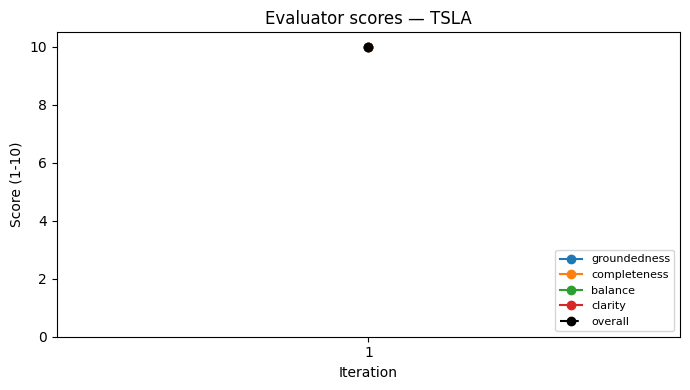

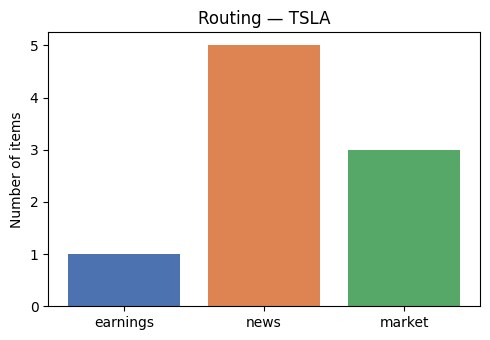

In [33]:
import matplotlib.pyplot as plt


def plot_score_trajectory(history, title="Evaluator scores by iteration"):
    """Line chart of each rubric criterion's score across evaluator-optimizer iterations."""
    iterations = [h["iteration"] for h in history]
    plt.figure(figsize=(7, 4))
    for c in RUBRIC:
        plt.plot(iterations, [h["review"]["scores"][c] for h in history],
                  marker="o", label=c)
    plt.plot(iterations, [h["review"]["overall"] for h in history],
              marker="o", linestyle="--", color="black", label="overall")
    plt.xlabel("Iteration")
    plt.ylabel("Score (1-10)")
    plt.title(title)
    plt.xticks(iterations)
    plt.ylim(0, 10.5)
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_route_distribution(decisions, title="Items routed per specialist"):
    """Bar chart of how many items the router sent to each specialist."""
    counts = {r: 0 for r in ROUTES}
    for d in decisions:
        counts[d["route"]] = counts.get(d["route"], 0) + 1
    plt.figure(figsize=(5, 3.5))
    plt.bar(list(counts.keys()), list(counts.values()),
            color=["#4C72B0", "#DD8452", "#55A868"])
    plt.ylabel("Number of items")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_score_trajectory(run3["history"], f"Evaluator scores \u2014 {run3['ticker']}")
plot_route_distribution(run3["decisions"], f"Routing \u2014 {run3['ticker']}")

# Other runs you can plot the same way:
# plot_score_trajectory(run1["history"], "Evaluator scores \u2014 AAPL")
# plot_score_trajectory(run2["history"], "Evaluator scores \u2014 NVDA")
# plot_route_distribution(run1["decisions"], "Routing \u2014 AAPL")


## Write-up: Agent Design and Workflows

> _Draft content — personalize this in your own words before submitting. It
> should read as your team's explanation, not a copy-pasted description._

**Architecture.** `run_agent(ticker, focus)` is the single entry point that
orchestrates the whole system: plan → gather data → route → draft/evaluate/
refine → reflect → remember. Each stage is a separate, testable function, and
each LLM call is made through one shared `llm_call()` wrapper (with caching
and retries) so the whole system uses one consistent path to the model.

**Data layer (tools).** Four tools sit behind a `TOOLS` registry: `price` and
`financials` and `news` from Yahoo Finance (`yfinance`), and `macro` from
FRED (fed funds rate, unemployment, 10-year Treasury yield, CPI inflation).
Yahoo Finance was the recommended starting point in the assignment brief;
FRED was added once early evaluator feedback kept flagging a lack of
macro/market-risk context in the reports.

**Workflow Pattern 1 — Prompt Chaining.** The news pipeline is five
sequential steps, each feeding the next: **Ingest** (`get_news`) →
**Preprocess** (`preprocess_news`: dedupe, strip HTML, cap length) →
**Classify** (`classify_news`: relevance/category/sentiment per article) →
**Extract** (`extract_facts`: key facts from relevant articles only) →
**Summarize** (`summarize_news`). Classification doubles as a filter: in
practice it routinely drops roughly half the raw headlines as not actually
about the target ticker.

**Workflow Pattern 2 — Routing.** `route_items` sends each piece of data
(price, financials, macro, individual news items) to exactly one of three
specialist analysts — **earnings**, **market**, **news** — based on content,
not source type, with a fallback route if the LLM's output is malformed.

**Workflow Pattern 3 — Evaluator–Optimizer.** `write_draft` produces a first
report from the specialists' analyses; `evaluate_report` fact-checks that
report against the original source items *before* scoring it (groundedness,
completeness, balance, clarity) and lists any unsupported claims;
`optimize_report` revises using that feedback. The loop runs up to 3
iterations and stops only when the score clears a threshold **and** no
unsupported claims remain — see "Evaluation and Iteration" for why both
conditions were necessary.


## Write-up: Agent Functions and Capabilities

> _Draft content — personalize this in your own words before submitting._

**Plans its research steps (`make_plan`).** Given a ticker and an optional
focus, the LLM returns a JSON list of steps, each naming one tool and a
reason. A focus like "valuation and price trend only" makes the planner
select only the matching tools and skip the rest; a general request uses
every tool that adds information. If the LLM call fails or returns nothing
usable, a default plan (all tools) is used instead, so planning failure
never stops the agent.

**Uses tools dynamically (`execute_plan`, `TOOLS`).** Only the tools the
plan actually names are called, in the order planned. Every tool call is
wrapped individually, so one tool failing (this happened live: the news
pipeline raised a `JSONDecodeError` on malformed model output) does not
stop the run — the agent continues with whatever data it has and reports
the gap rather than crashing.

**Self-reflects (`self_reflect`).** This is intentionally separate from the
evaluator–optimizer. The evaluator checks whether the *report's claims* are
supported by the data. Self-reflection checks the *agent's own process* for
this run: was the plan appropriate, did any tool fail, is any topic weakly
covered, and — most usefully — what would it do differently next time. That
last answer is what memory stores.

**Learns across runs (memory).** Notes are saved as JSON on Google Drive
(`memory.json`), keyed by ticker, so they persist across Colab sessions —
not just within one notebook run. `run_agent` reads a ticker's past notes
before planning (and passes them into the planner's prompt) and writes a new
note after reflecting. The demonstration below (`run3`, then `run4` on the
same ticker) shows the second run picking up the first run's note.


## Write-up: Evaluation and Iteration

> _Draft content — personalize this in your own words, and paste your own
> run's printed output (plan, scores, reflection) below before exporting.
> A grader will want this narrative tied to real console evidence, not just
> prose._

#### What we found and fixed (with evidence from real runs)

**v1 evaluator was too lenient.** The first design scored the report and
stopped once the *average* score cleared a threshold. On one AAPL run it
scored `groundedness=9, completeness=9, balance=7, clarity=9` (**overall
8.5**) and passed with **no revision at all** — even though the report
contained an unverified claim ("architecture protects against emerging AI
threats," attributed to "company announcements") that a promotional news
source did not actually support.

**v2 added fact-checking first, but exposed a new bug.** We changed the
evaluator to list unsupported claims *before* scoring, and required both
`overall >= threshold` **and** zero unsupported claims to stop. A rerun
correctly caught real problems (meta-commentary like "in the provided
text," and a claim wrongly attributed to "company announcements") across
three iterations: **7.5 → 8.2 → 7.8**. This revealed that scores are
*not* monotonic — the loop was returning the **last** iteration (7.8),
which was worse than iteration 2 (8.2).

**v3 fixed the stopping/selection logic and tightened sourcing rules.** We
changed the loop to keep the best-scoring iteration with the fewest
unsupported claims (not just the last one), and added rules requiring the
writer to attribute news claims by publisher name and hedge unconfirmed
ones ("hints at," "reportedly"). A later NVDA run went **8.2 → 7.2 → 9.2**
and correctly kept iteration 3; it also correctly softened an ambiguous
source ("two tech giants," not explicitly named) instead of flatly
attributing it to the target company.

**Most recent runs in this notebook:** the AAPL run above reached
**9.0 → 9.8** (kept iteration 2) and the NVDA run reached **8.8 → 9.5**
(kept iteration 2) — both cleared with zero unsupported claims.

#### What this version adds (not yet run — paste your output above/below once you do)

- **`llm_json` retries with a stricter prompt** instead of trusting a cached
  malformed reply, after a live run hit a `JSONDecodeError` mid-pipeline.
  (The agent survived that failure gracefully at the time, since
  `execute_plan` isolates tool errors — this fix reduces how often it
  happens at all.)
- **`make_plan` now actually restricts tools when the focus says "only"**,
  and accepts notes from memory.
- **Self-reflection and memory** are new agent functions layered on top of
  the same evaluator–optimizer and routing pipeline.

#### Known limitations

- **LLM-as-judge noise.** The evaluator's scores are not perfectly
  consistent between runs and can raise a new complaint each round even as
  real problems get fixed.
- **Thin or promotional sources.** When only 1–2 news items survive
  filtering, the writer is often forced into hedged, attributed language
  rather than confident claims — a correct but visibly cautious report.
- **Live data changes between runs by design.** Prices, financials, and
  macro figures are fetched fresh each time, so re-running the same ticker
  on a different day will show different numbers — this is expected
  behavior, not a bug, and memory notes are written to account for it.


## Submission Checklist (mapped to the grading rubric)

**Workflow Patterns (33.8%)**
- [x] Prompt chaining — Ingest → Preprocess → Classify → Extract → Summarize (news pipeline)
- [x] Routing — router assigns items to Earnings / Market / News specialists
- [x] Evaluator–Optimizer — draft → fact-check & score → refine, best iteration kept

**Agent Functions (33.8%)**
- [x] Plans research steps per ticker (`make_plan`)
- [x] Uses tools dynamically (`execute_plan`, `TOOLS` registry: price, financials, news, macro)
- [x] Self-reflects on its own process (`self_reflect`) — separate from the evaluator's fact-check
- [x] Learns across runs via persistent memory (`memory.json` on Google Drive)

**Code (32.4%)**
- [ ] Team GitHub repository link added at the top of this notebook and in the repo's README
- [ ] README added to the GitHub repo
- [ ] Code follows PEP 8 (e.g. `!pip install flake8 -q` then lint before export)
- [ ] Every cell runs top-to-bottom without errors before export (Runtime → Run all)
- [ ] Exported as **PDF** (preferred) or HTML — File → Print → Save as PDF, or File → Download → Download .html
- [ ] Write-up sections above completed in your own words, with your own run's output pasted in
- [ ] At least one visualization included (see Visualizations section above)
- [ ] Individual peer evaluation submitted separately in Module 7

**Before your final run:** watch your Gemini free-tier daily quota
(`aistudio.google.com/rate-limit`) — a full `run_agent` call costs roughly
12–15 requests, so budget for at least two full runs (AAPL/NVDA demo plus
the TSLA memory demo) on submission day.
